In [1]:
import sys
import os

# Set working directory explicitly to project root (/home/jovyan/work)
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
os.chdir(project_root)
if project_root not in sys.path:
    sys.path.append(project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, f1_score, accuracy_score

from src.core.config import get_model_params, get_feature_list
from src.data.spark_pipeline import get_spark_session
from src.data.databricks_client import DatabricksClient
from src.models.regression import StockPriceRegressor
from src.models.classification import StockClassifier

print("Phase 5 imports and path setup successful!")

Phase 5 imports and path setup successful!


In [2]:
# 1. Initialize sessions & client
spark = get_spark_session()
db_client = DatabricksClient()

# 2. Read stored indicators and sentiment tables
indicators_df = db_client.read_dataset(spark, table_name="aapl_indicators").toPandas()
sentiment_df = db_client.read_dataset(spark, table_name="aapl_sentiment").toPandas()

# 3. Convert timestamps and align datasets on date
indicators_df["date"] = pd.to_datetime(indicators_df["date"])
sentiment_df["date"] = pd.to_datetime(sentiment_df["timestamp"]).dt.date
sentiment_df["date"] = pd.to_datetime(sentiment_df["date"])

# Aggregate daily sentiment score averages
daily_sentiment = (
    sentiment_df.groupby(["date", "ticker"])[
        ["neg_score", "neu_score", "pos_score", "compound_score"]
    ]
    .mean()
    .reset_index()
)

# Merge technical features with sentiment features
df = pd.merge(indicators_df, daily_sentiment, on=["date", "ticker"], how="left").fillna(0)
df = df.sort_values("date").reset_index(drop=True)

print(f"Merged Dataset Shape: {df.shape}")
df.head()

[2026-09-24 22:40:44] [INFO] [stonks_maker]: Reading dataset locally from /home/jovyan/work/data/processed/aapl_indicators
[2026-09-24 22:40:48] [INFO] [stonks_maker]: Reading dataset locally from /home/jovyan/work/data/processed/aapl_sentiment
Merged Dataset Shape: (251, 17)


,date,ticker,open,high,low,close,adj_close,volume,sma_20,sma_50,bollinger_upper,bollinger_lower,rsi_14,neg_score,neu_score,pos_score,compound_score
0,2025-09-25,AAPL,252.278088,256.223520,250.783609,255.924606,255.924606,55202100,255.924606,255.924606,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
1,2025-09-26,AAPL,253.164811,256.651929,252.845981,254.519806,254.519806,46076300,255.222206,255.222206,257.208894,253.235518,0.000000,0.0,0.0,0.0,0.0
2,2025-09-29,AAPL,253.623133,254.061516,252.078834,253.493607,253.493607,40127700,254.646006,254.646006,257.086813,252.205199,0.000000,0.0,0.0,0.0,0.0
3,2025-09-30,AAPL,253.922005,254.978101,252.178446,253.692856,253.692856,37704300,254.407719,254.407719,256.616834,252.198604,7.575289,0.0,0.0,0.0,0.0
4,2025-10-01,AAPL,254.101347,257.837561,253.991751,254.509842,254.509842,48713900,254.428143,254.428143,256.343472,252.512814,29.479680,0.0,0.0,0.0,0.0


In [3]:
# Instantiate regression and classification wrappers
# Hyperparameters and feature definitions load dynamically from config/model_params.yaml
regressor = StockPriceRegressor()
X_reg, y_reg = regressor.prepare_data(df, target_horizon=1)

classifier = StockClassifier()
clf_df = classifier.prepare_data(df)

feature_cols = regressor.feature_names
X_clf = clf_df[feature_cols]
y_dir = clf_df["target_direction"]
y_strat = clf_df["target_strategy"]

# Time-Series Split Cross-Validation (5 Folds)
tscv = TimeSeriesSplit(n_splits=5)

rmse_scores, mae_scores, r2_scores = [], [], []
dir_f1_scores = []

print("Executing Time-Series Split Cross-Validation...\n")

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_reg), 1):
    X_tr_r, X_val_r = X_reg.iloc[train_idx], X_reg.iloc[val_idx]
    y_tr_r, y_val_r = y_reg.iloc[train_idx], y_reg.iloc[val_idx]
    
    # Train Regressor
    regressor.train(X_tr_r, y_tr_r)
    preds_r = regressor.model.predict(X_val_r)
    
    # Calculate RMSE (compatible with scikit-learn 1.3.2)
    rmse = np.sqrt(mean_squared_error(y_val_r, preds_r))
    mae = mean_absolute_error(y_val_r, preds_r)
    r2 = r2_score(y_val_r, preds_r)
    
    rmse_scores.append(rmse)
    mae_scores.append(mae)
    r2_scores.append(r2)
    
    # Train Direction Classifier
    X_tr_c, X_val_c = X_clf.iloc[train_idx], X_clf.iloc[val_idx]
    classifier.train_direction(X_tr_c, y_dir.iloc[train_idx])
    
    dir_preds = classifier.direction_model.predict(X_val_c)
    dir_f1 = f1_score(y_dir.iloc[val_idx], dir_preds, average="weighted")
    dir_f1_scores.append(dir_f1)
    
    print(f"Fold {fold} -> Regressor RMSE: {rmse:.4f} | R2: {r2:.4f} | Direction F1: {dir_f1:.4f}")

print("\n--- Cross-Validation Summary ---")
print(f"Mean RMSE: {np.mean(rmse_scores):.4f} (± {np.std(rmse_scores):.4f})")
print(f"Mean MAE:  {np.mean(mae_scores):.4f}")
print(f"Mean R2:   {np.mean(r2_scores):.4f}")
print(f"Mean Directional Weighted F1: {np.mean(dir_f1_scores):.4f}")

Executing Time-Series Split Cross-Validation...

[2026-09-24 22:40:48] [INFO] [stonks_maker]: Training Stock Price Regressor...
[2026-09-24 22:40:48] [INFO] [stonks_maker]: Regressor training completed.
[2026-09-24 22:40:48] [INFO] [stonks_maker]: Training Movement Direction Classifier (UP/DOWN)...
Fold 1 -> Regressor RMSE: 0.0110 | R2: -0.1894 | Direction F1: 0.4198
[2026-09-24 22:40:48] [INFO] [stonks_maker]: Training Stock Price Regressor...
[2026-09-24 22:40:48] [INFO] [stonks_maker]: Regressor training completed.
[2026-09-24 22:40:48] [INFO] [stonks_maker]: Training Movement Direction Classifier (UP/DOWN)...
Fold 2 -> Regressor RMSE: 0.0161 | R2: 0.0276 | Direction F1: 0.5854
[2026-09-24 22:40:48] [INFO] [stonks_maker]: Training Stock Price Regressor...
[2026-09-24 22:40:49] [INFO] [stonks_maker]: Regressor training completed.
[2026-09-24 22:40:49] [INFO] [stonks_maker]: Training Movement Direction Classifier (UP/DOWN)...
Fold 3 -> Regressor RMSE: 0.0162 | R2: -0.4774 | Direction 

[2026-09-24 22:40:49] [INFO] [stonks_maker]: Training Stock Price Regressor...
[2026-09-24 22:40:49] [INFO] [stonks_maker]: Regressor training completed.


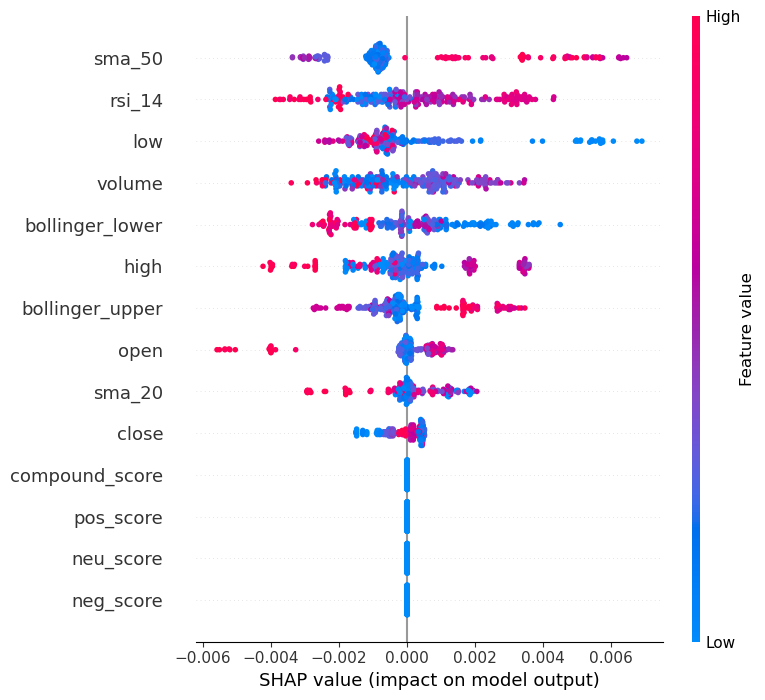

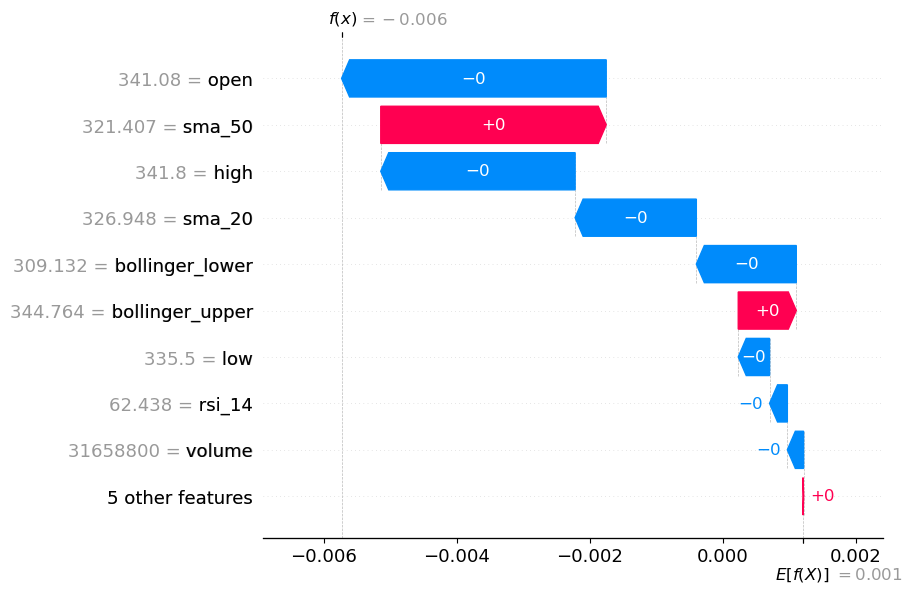

In [4]:
# Train regressor on full dataset to explain global and instance feature attributions
regressor.train(X_reg, y_reg)

# Compute SHAP Values using TreeExplainer
explainer = shap.TreeExplainer(regressor.model)
shap_values = explainer(X_reg)

# 1. SHAP Summary Plot
plt.figure()
shap.summary_plot(shap_values, X_reg, feature_names=feature_cols)

# 2. SHAP Waterfall Plot for the latest instance
plt.figure()
shap.plots.waterfall(shap_values[-1])

In [5]:
# Retrain classification models on full dataset
classifier.train_direction(X_clf, y_dir)
classifier.train_strategy(X_clf, y_strat)

# Save binaries to models/ directory
os.makedirs("models", exist_ok=True)
regressor.save_model("models/regressor.joblib")
classifier.save_models()

print("Phase 5 Complete! Updated model binaries saved to ./models/")

[2026-09-24 22:40:50] [INFO] [stonks_maker]: Training Movement Direction Classifier (UP/DOWN)...
[2026-09-24 22:40:50] [INFO] [stonks_maker]: Training Strategy Classifier (Day vs Swing)...
[2026-09-24 22:40:50] [INFO] [stonks_maker]: Regressor saved to models/regressor.joblib
[2026-09-24 22:40:50] [INFO] [stonks_maker]: Classifier models saved successfully.
Phase 5 Complete! Updated model binaries saved to ./models/
